<a href="https://colab.research.google.com/github/farshanabegam/AIML_Brain-tumour-classification/blob/main/Brain_Tumor_MRI_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Tumour"

print(os.listdir(dataset_path))

['README.dataset.txt', 'test', 'valid', 'train']


In [ ]:
import os

train_path = "/content/drive/MyDrive/Tumour/train"
valid_path = "/content/drive/MyDrive/Tumour/valid"
test_path = "/content/drive/MyDrive/Tumour/test"
print(os.listdir(train_path))

['_classes.csv', 'pituitary', 'glioma', 'no_tumor', 'meningioma']


In [ ]:
import os

classes = [f for f in os.listdir(train_path)
           if os.path.isdir(os.path.join(train_path, f))]

for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"{cls}: {count}")

pituitary: 438
glioma: 564
no_tumor: 335
meningioma: 358


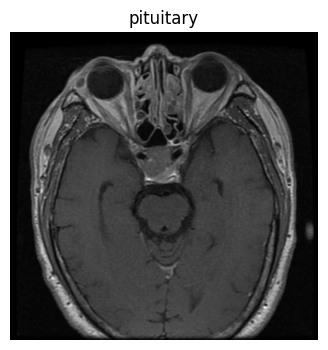

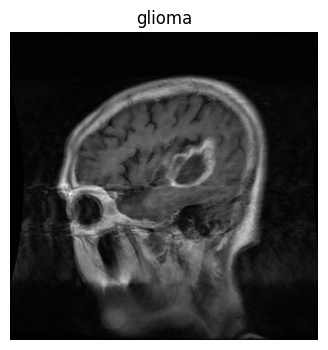

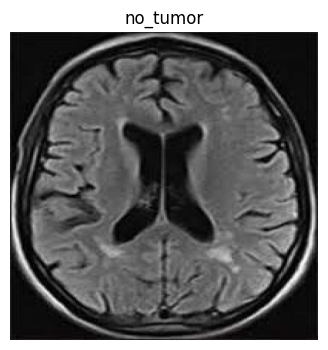

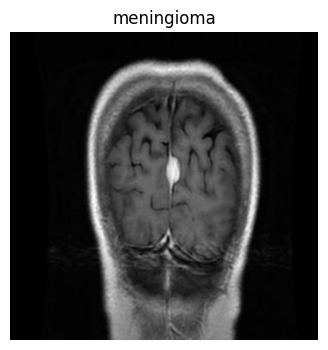

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

for cls in classes:
    folder = os.path.join(train_path, cls)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

In [ ]:
from PIL import Image
import os

sample_class = classes[0]

sample_img = os.listdir(os.path.join(train_path, sample_class))[0]

img_path = os.path.join(train_path, sample_class, sample_img)

img = Image.open(img_path)

print("Image Size:", img.size)

Image Size: (640, 640)


In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [ ]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(4, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [ ]:
history = cnn_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4458 - loss: 1.5851

53/53 ━━━━━━━━━━━━━━━━━━━━ 544s 10s/step - accuracy: 0.4779 - loss: 1.4812 - val_accuracy: 0.2351 - val_loss: 64.2531
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 356s 7s/step - accuracy: 0.4791 - loss: 1.2453 - val_accuracy: 0.2351 - val_loss: 45.9483
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 376s 7s/step - accuracy: 0.5056 - loss: 1.1736 - val_accuracy: 0.2351 - val_loss: 13.6065
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5357 - loss: 1.1489

53/53 ━━━━━━━━━━━━━━━━━━━━ 375s 7s/step - accuracy: 0.5487 - loss: 1.1370 - val_accuracy: 0.2371 - val_loss: 7.5381
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5628 - loss: 1.1093

53/53 ━━━━━━━━━━━━━━━━━━━━ 452s 8s/step - accuracy: 0.5516 - loss: 1.0783 - val_accuracy: 0.3884 - val_loss: 2.0650
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 356s 7s/step - accuracy: 0.5870 - loss: 1.0715 - val_accuracy: 0.3406 - val_loss: 5.3071
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5939 - loss: 0.9896

53/53 ━━━━━━━━━━━━━━━━━━━━ 377s 7s/step - accuracy: 0.5593 - loss: 1.0336 - val_accuracy: 0.4024 - val_loss: 1.4613
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6157 - loss: 0.9302

53/53 ━━━━━━━━━━━━━━━━━━━━ 357s 7s/step - accuracy: 0.5923 - loss: 0.9608 - val_accuracy: 0.6036 - val_loss: 0.9179
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 360s 7s/step - accuracy: 0.5516 - loss: 0.9699 - val_accuracy: 0.5697 - val_loss: 0.9238
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5606 - loss: 1.0450

53/53 ━━━━━━━━━━━━━━━━━━━━ 358s 7s/step - accuracy: 0.5681 - loss: 1.0070 - val_accuracy: 0.6335 - val_loss: 0.8621
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 356s 7s/step - accuracy: 0.5611 - loss: 1.0069 - val_accuracy: 0.4861 - val_loss: 1.3091
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 367s 7s/step - accuracy: 0.5434 - loss: 1.0061 - val_accuracy: 0.5876 - val_loss: 1.2192
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - accuracy: 0.5912 - loss: 1.0105 - val_accuracy: 0.5837 - val_loss: 1.5558
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5651 - loss: 0.9596

53/53 ━━━━━━━━━━━━━━━━━━━━ 371s 7s/step - accuracy: 0.5664 - loss: 0.9644 - val_accuracy: 0.6952 - val_loss: 0.8399
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 369s 7s/step - accuracy: 0.5516 - loss: 1.0420 - val_accuracy: 0.4920 - val_loss: 1.6467


In [ ]:
import os
print(os.listdir())

['.config', 'best_cnn_model.h5', 'mobilenet_brain_tumor.h5', 'drive', 'sample_data']


In [ ]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2073 - loss: 1.3901
Test Accuracy: 0.2073170691728592
Test Loss: 1.3900729417800903


In [ ]:
print(train_generator.samples)
print(valid_generator.samples)
print(test_generator.samples)

1695
502
246


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
              precision    recall  f1-score   support

      glioma       0.00      0.00      0.00        80
  meningioma       0.27      0.59      0.37        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.35      0.70      0.47        54

    accuracy                           0.30       246
   macro avg       0.16      0.32      0.21       246
weighted avg       0.15      0.30      0.20       246



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


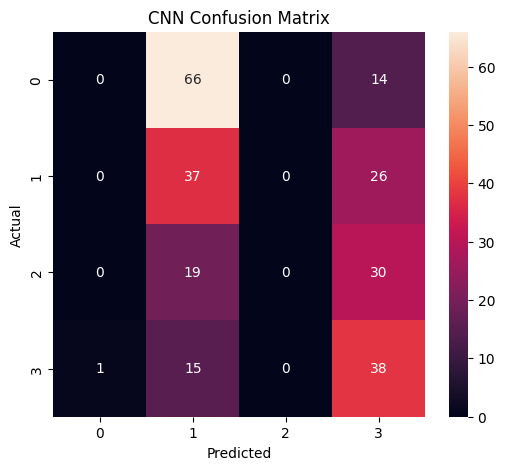

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "mobilenet_brain_tumor.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8434 - loss: 0.4202

53/53 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8496 - loss: 0.4112 - val_accuracy: 0.8506 - val_loss: 0.4206
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8469 - loss: 0.3972

53/53 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8637 - loss: 0.3591 - val_accuracy: 0.8705 - val_loss: 0.3631
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8814 - loss: 0.3244 - val_accuracy: 0.8546 - val_loss: 0.4070
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8926 - loss: 0.2996 - val_accuracy: 0.8486 - val_loss: 0.3904
Epoch 5/10
 4/53 ━━━━━━━━━━━━━━━━━━━━ 1:53 2s/step - accuracy: 0.9316 - loss: 0.2312

In [ ]:
test_loss, test_acc = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Test Accuracy:", test_acc)
print("MobileNetV2 Test Loss:", test_loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8293 - loss: 0.4232
MobileNetV2 Test Accuracy: 0.8292682766914368
MobileNetV2 Test Loss: 0.42318207025527954


In [ ]:
mobilenet_model.save("mobilenet_brain_tumor.h5")

In [ ]:
import os

print(os.listdir())

['.config', 'mobilenet_brain_tumor.h5', 'best_cnn_model.h5', 'drive', 'sample_data']


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

predictions = mobilenet_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step
              precision    recall  f1-score   support

      glioma       0.87      0.91      0.89        80
  meningioma       0.79      0.60      0.68        63
    no_tumor       0.85      0.80      0.82        49
   pituitary       0.79      1.00      0.89        54

    accuracy                           0.83       246
   macro avg       0.83      0.83      0.82       246
weighted avg       0.83      0.83      0.82       246



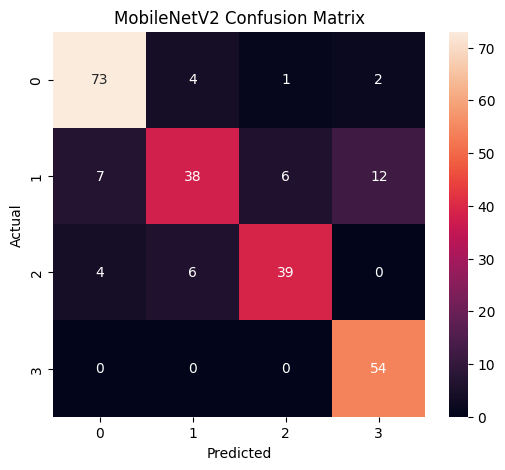

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_generator.classes,
    y_pred
)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

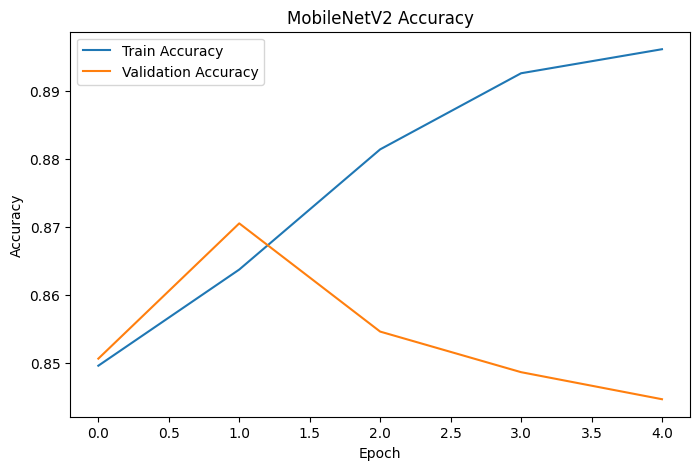

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

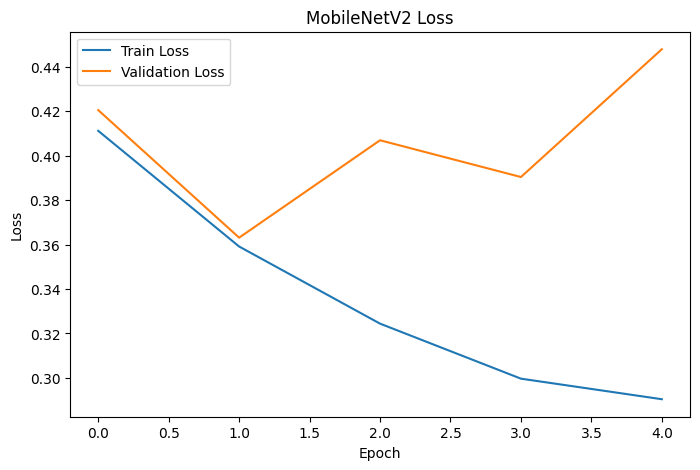

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import os
print(os.listdir())

['.config', 'mobilenet_brain_tumor.h5', 'best_cnn_model.h5', 'drive', 'sample_data']


In [ ]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 55.7 MB/s eta 0:00:00
--2026-06-05 20:05:54--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.5.2/cloudflared-linux-amd64 [following]
--2026-06-05 20:05:55--  https://github.com/cloudflare/cloudflared/releases/download/2026.5.2/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/49ed726b-742b-4dbe-a0cf-d9efc4d22773?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-05T21%3A06%3A08Z&rscd=attachment%3B+filename%3Dcl

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
import pandas as pd
from PIL import Image

# -----------------------------------

# Page Configuration

# -----------------------------------

st.set_page_config(
page_title="Brain Tumor MRI Classification",
page_icon="🧠",
layout="wide"
)

# -----------------------------------

# Load Model

# -----------------------------------

@st.cache_resource
def load_model():
  return tf.keras.models.load_model("mobilenet_brain_tumor.h5")

model = load_model()

# -----------------------------------

# Class Names

# -----------------------------------

class_names = [
"glioma",
"meningioma",
"no_tumor",
"pituitary"
]

# -----------------------------------

# Sidebar

# -----------------------------------

st.sidebar.title("🧠 Brain Tumor MRI Classification")

st.sidebar.markdown("""

### Project Information

**Model Used:** MobileNetV2

**Dataset Classes**

* Glioma
* Meningioma
* No Tumor
* Pituitary

### Technologies Used

* Deep Learning
* TensorFlow / Keras
* Transfer Learning
* Streamlit

### Best Model Performance

* Test Accuracy: 82.93%
* Test Loss: 0.4232
  """)

# -----------------------------------

# Main Title

# -----------------------------------

st.title("🧠 Brain Tumor MRI Classification System")

st.markdown("""
This AI-powered application classifies Brain MRI images into different tumor categories using a pretrained MobileNetV2 model.

### Supported Classes

* Glioma
* Meningioma
* No Tumor
* Pituitary

Upload a Brain MRI image below and get instant predictions.
""")

st.divider()

# -----------------------------------

# File Upload

# -----------------------------------

uploaded_file = st.file_uploader(
"📤 Upload Brain MRI Image",
type=["jpg", "jpeg", "png"]
)

# -----------------------------------

# Prediction Section

# -----------------------------------

if uploaded_file is not None:


    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns(2)

    with col1:
        st.image(
        image,
        caption="Uploaded MRI Image",
        use_container_width=True
    )

# Image Preprocessing
img = image.resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

with col2:

    st.subheader("📋 Prediction Result")

    st.success(
        f"Predicted Tumor Type: {class_names[predicted_class]}"
    )

    st.info(
        f"Confidence Score: {confidence:.2f}%"
    )

    if confidence >= 90:
        st.success("Very High Confidence Prediction")
    elif confidence >= 75:
        st.warning("Good Confidence Prediction")
    else:
        st.error("Low Confidence Prediction")

# -----------------------------------
# Probability Chart
# -----------------------------------
st.subheader("📊 Prediction Probabilities")

prob_df = pd.DataFrame({
    "Tumor Type": class_names,
    "Probability (%)": prediction[0] * 100
})

st.bar_chart(
    prob_df.set_index("Tumor Type")
)

st.dataframe(prob_df)


st.divider()

# -----------------------------------

# Project Summary

# -----------------------------------

st.markdown("""

## 📌 Project Summary

This project uses Deep Learning and Transfer Learning techniques to classify Brain MRI scans.

### Workflow

✔ Data Preprocessing

✔ Data Augmentation

✔ Custom CNN Development

✔ MobileNetV2 Transfer Learning

✔ Model Evaluation

✔ Streamlit Deployment

### Final Result

🏆 Best Model: MobileNetV2

📈 Test Accuracy: 82.93%

📉 Test Loss: 0.4232
""")


Overwriting app.py


In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://simple-mainly-while-beginning.trycloudflare.com
